<h1><center>Stock Analysis</center></h1>

Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from alpha_vantage.timeseries import TimeSeries
from alpha_vantage.fundamentaldata import FundamentalData
from alpha_vantage.techindicators import TechIndicators
from alpha_vantage.econindicators import EconIndicators
from dotenv import load_dotenv
import os
import datetime


Import API and retrieve data

In [2]:
load_dotenv()

True

In [3]:
# Imports data
ts = TimeSeries('api_key', output_format='pandas')

stock, meta = ts.get_daily(symbol='QBTS', outputsize='full')

stock.head()

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2025-10-31,35.9900,37.435,35.055,37.06,37780289.0
2025-10-30,32.9100,36.790,32.450,36.11,44418015.0
2025-10-29,32.4750,34.650,32.000,34.26,47219167.0
2025-10-28,35.2954,36.570,31.850,32.00,64548472.0
2025-10-27,33.9900,37.280,33.230,35.04,65054302.0


In [4]:
# View colmns
stock.columns

Index(['1. open', '2. high', '3. low', '4. close', '5. volume'], dtype='object')

In [5]:
# Rename columns
stock.rename(columns={'1. open': 'open', '2. high': 'high', '3. low': 'low', 
'4. close': 'close', '5. volume': 'volume'}, inplace = True)

In [6]:
# view first 5 rows to ensure column names changed.
stock.head()

,open,high,low,close,volume
date,,,,,
2025-10-31,35.9900,37.435,35.055,37.06,37780289.0
2025-10-30,32.9100,36.790,32.450,36.11,44418015.0
2025-10-29,32.4750,34.650,32.000,34.26,47219167.0
2025-10-28,35.2954,36.570,31.850,32.00,64548472.0
2025-10-27,33.9900,37.280,33.230,35.04,65054302.0


In [7]:
stock.tail()

,open,high,low,close,volume
date,,,,,
2022-08-12,11.36,11.5999,10.23,10.86,234128.0
2022-08-11,12.10,12.6999,11.35,11.86,282018.0
2022-08-10,11.71,13.2300,10.50,12.11,827034.0
2022-08-09,10.43,12.5000,7.50,12.40,940281.0
2022-08-08,8.98,13.1175,8.75,10.00,1461459.0


In [8]:
stock.shape

(813, 5)

In [9]:
ta = TechIndicators('api_key', output_format = 'pandas')

In [10]:
fd = FundamentalData('api_key' , output_format = 'pandas')

In [11]:
qbts, meta = ta.get_sma(symbol='QBTS')

In [12]:
qbts.shape

(794, 1)

In [13]:
qbts.head()

,SMA
date,
2025-10-31,35.6195
2025-10-30,35.4015
2025-10-29,35.0565
2025-10-28,34.6250
2025-10-27,34.2605


In [14]:
qbts.tail()

,SMA
date,
2022-09-09,8.1410
2022-09-08,8.3950
2022-09-07,8.6570
2022-09-06,8.9740
2022-09-02,9.1925


In [15]:
qbts_div = fd.get_dividends('QBTS')

In [16]:
qbts_div 

(Empty DataFrame
 Columns: []
 Index: [],
 'QBTS')

In [17]:
qbts_split = fd.get_splits('QBTS')

In [18]:
qbts_split

(Empty DataFrame
 Columns: []
 Index: [],
 'QBTS')

<h1><center>EDA</center><h1>

In [19]:
stock.dtypes

open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object

In [20]:
stock['pct_ch_clo'] = stock['close'].pct_change() * 100

In [21]:
stock['pct_ch_clo'] = stock['pct_ch_clo'].round(2)

In [22]:
stock.head()

,open,high,low,close,volume,pct_ch_clo
date,,,,,,
2025-10-31,35.9900,37.435,35.055,37.06,37780289.0,NaN
2025-10-30,32.9100,36.790,32.450,36.11,44418015.0,-2.56
2025-10-29,32.4750,34.650,32.000,34.26,47219167.0,-5.12
2025-10-28,35.2954,36.570,31.850,32.00,64548472.0,-6.60
2025-10-27,33.9900,37.280,33.230,35.04,65054302.0,9.50


In [23]:
stock.tail()

,open,high,low,close,volume,pct_ch_clo
date,,,,,,
2022-08-12,11.36,11.5999,10.23,10.86,234128.0,1.50
2022-08-11,12.10,12.6999,11.35,11.86,282018.0,9.21
2022-08-10,11.71,13.2300,10.50,12.11,827034.0,2.11
2022-08-09,10.43,12.5000,7.50,12.40,940281.0,2.39
2022-08-08,8.98,13.1175,8.75,10.00,1461459.0,-19.35


In [24]:
# Function to calculate Sharpe Ratio.
def calculate_sharp_ratio(ret, ann_rfr, periods):
    daily_rfr = ann_rfr/periods
    excess_ret = ret-daily_rfr
    mean_ex_ret = excess_ret.mean()
    std_ex_ret = excess_ret.std()

    if std_ex_ret == 0:
        return np.nan

    sharp_ratio = (mean_ex_ret/std_ex_ret) * np.sqrt(periods)

    return sharp_ratio

In [25]:
# call function to calculate Sharpe Ratio.
ann_rfr = 0.0377
periods = 252
ret = stock['pct_ch_clo']
sharpe = calculate_sharp_ratio(ret, ann_rfr, periods).round(2)
print(f"The Sharpe ratio for QBTS is:\n{sharpe}")

The Sharpe ratio for QBTS is:
0.44


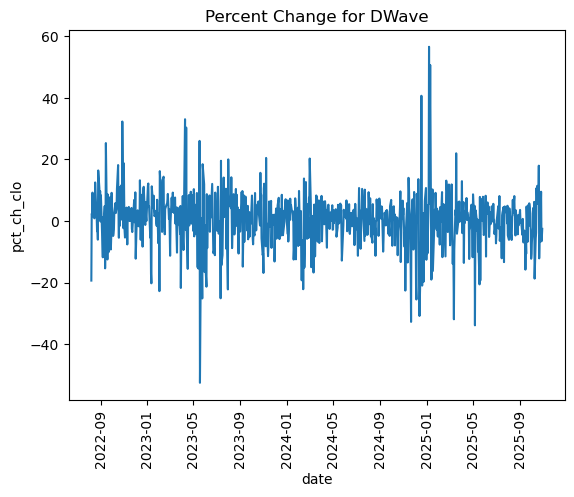

In [26]:
sns.lineplot(stock, x = 'date', y = 'pct_ch_clo')
plt.title('Percent Change for DWave')
plt.xticks(rotation=90)
plt.show()

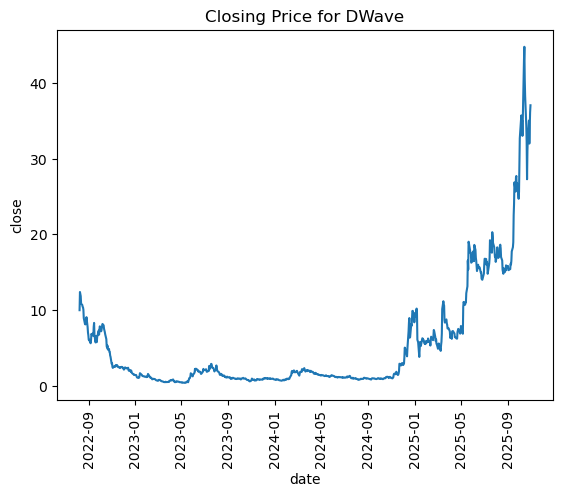

In [27]:
sns.lineplot(stock, x = 'date', y = 'close')
plt.title('Closing Price for DWave')
plt.xticks(rotation= 90)
plt.show()

In [28]:
stock_qbts = pd.merge(stock, qbts, on='date', how='inner')

In [30]:
stock_qbts = stock_qbts.fillna(0)

In [31]:
stock_qbts.head()

,open,high,low,close,volume,pct_ch_clo,SMA
date,,,,,,,
2025-10-31,35.9900,37.435,35.055,37.06,37780289.0,0.00,35.6195
2025-10-30,32.9100,36.790,32.450,36.11,44418015.0,-2.56,35.4015
2025-10-29,32.4750,34.650,32.000,34.26,47219167.0,-5.12,35.0565
2025-10-28,35.2954,36.570,31.850,32.00,64548472.0,-6.60,34.6250
2025-10-27,33.9900,37.280,33.230,35.04,65054302.0,9.50,34.2605
